## OPTIMIZERS

1. **What is an Optimizer. What is the role of Optimizer in the Neural Networks?**
   - An optimizer is an algorithm that is used to reduce the loss(error) , By updating the weights and biases
   - The main role of optimizer is to find the best set of weights , such that the model performs well
2. **Few popular Optimizers that are used in Neural Networks**
   - Gradient Descent [Stochasatic Gradient Descent, Batch Gradient Descent, MiniBatch Gradient Descent]
   - Nesterov accelarated gradienty
   - Adagrad
   - Adadelta
   - RMSprop
   - Adam

### Gradient Descent
- The procedure of repeatedly finding the gradient then performing a parameter update is called Gradient Descent
- There are three variants of the gradient descent , Based on how much data we use to compute the gradient of the objective function.
- Depending on the amount of data, We make a trade-off between the accuracy of the parameter update and the time it takes to perform an update
1. **Batch gradient descent**
$$
w = w - \eta \cdot \frac{1}{N} \sum_{i=1}^{N} \nabla L_i(w)
$$
   - In batch gradient descent entire dataset is considered for training at once , We calculate the gradients for whole dataset to perform just one update
   - Because of this Batch gradient descent is slow , learning rate determines how big of an update we perform
   - Batch gradient descent is guaranted to converge to the global minimum for convex loss function like (MSE)
2. **Stochastic gradient descent**
$$
w = w - \eta \cdot \nabla L_i(w)
$$ 
   - **∇Lᵢ(w)** → Gradient of loss for i-th sample
   - In stochastic gradient descent we select one observation randomly at a time we pass to training for every iteration weights get updated
   - Because of noisy update escapes from local minimum , convergence is guaranted but
   - Due to many updates , follows zig-zag(noisy) path takes time to convergence
3. **Mini Batch gradient descent**
   - Better compramise between batch and stochastic gradient descent
   - Training is performed on the batches, dataset is divided into batches
$$
w = w - \eta \cdot \frac{1}{B} \sum_{i=1}^{B} \nabla L_i(w)
$$

#### Limitations:
   - Struct at local minima and saddle points


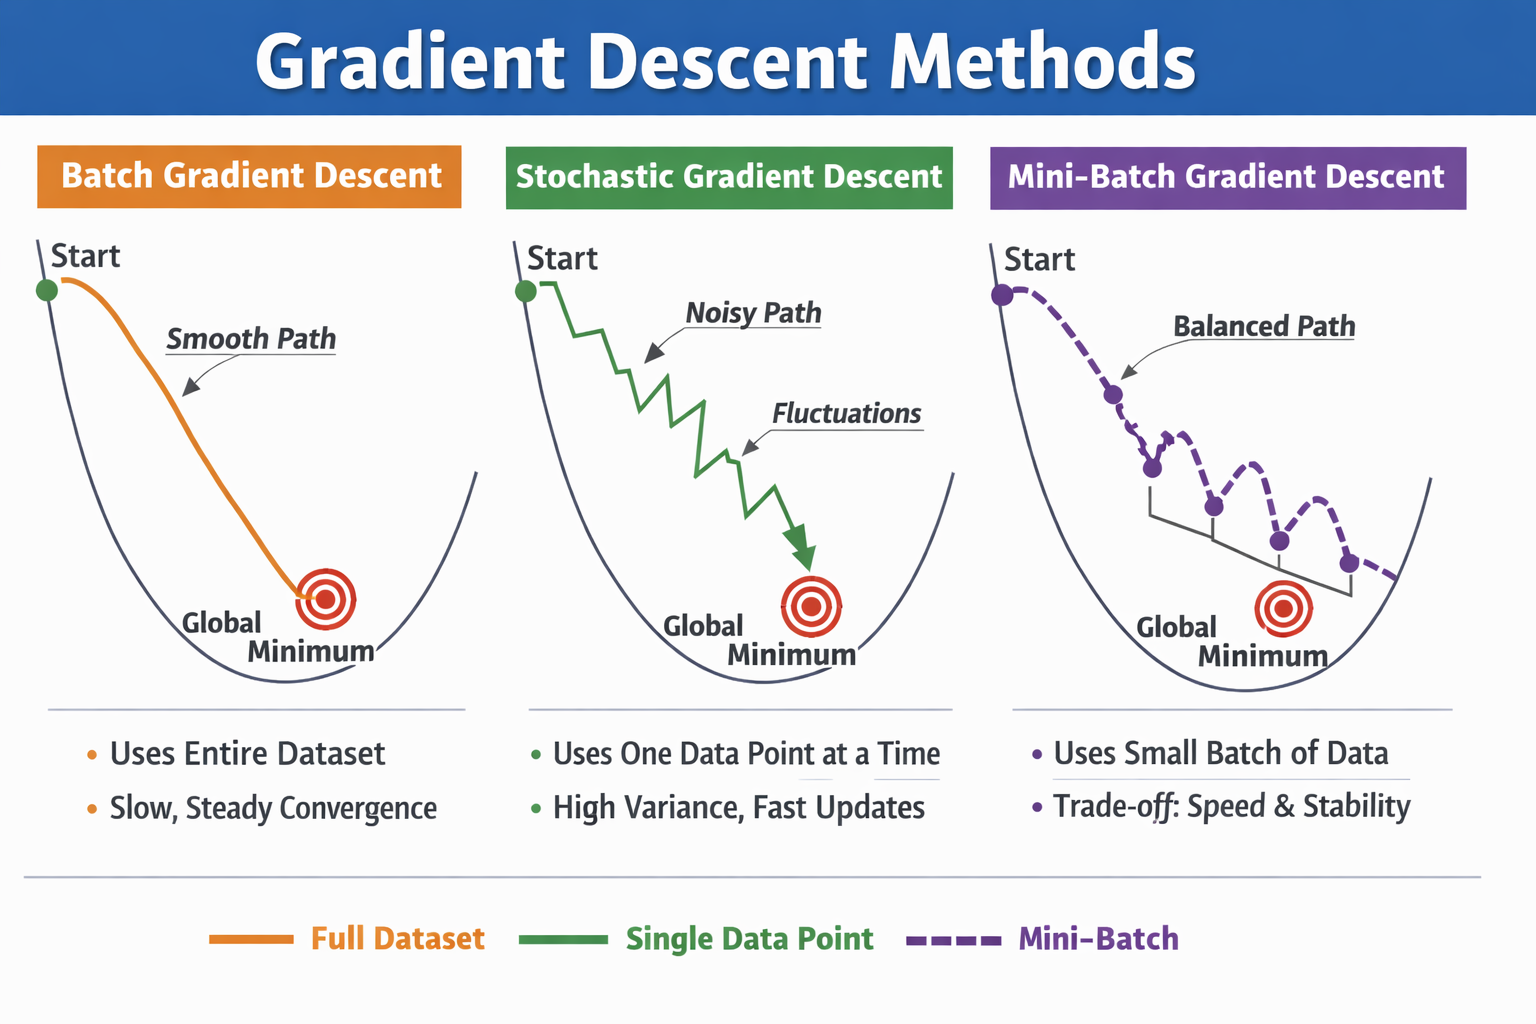

---

### Nestrov Accelerated Gradient
   - NAG is a momentum based optimization method that improves convergence speed and stability by computing the `look ahead gradients`
   - We build a velocity based on past gradients , but we compute gradient at the current position avoids overshooting
   - Velocity update:
$$
v_{t+1} = \gamma v_t - \eta \nabla f(\theta_t + \gamma v_t)
$$
   - Parameter update:
$$
\theta_{t+1} = \theta_t + v_{t+1}
$$
#### Limitaions:
   - NAG heavily depends on choosing the right learning rate, if its too high oscillates takes time for convergence
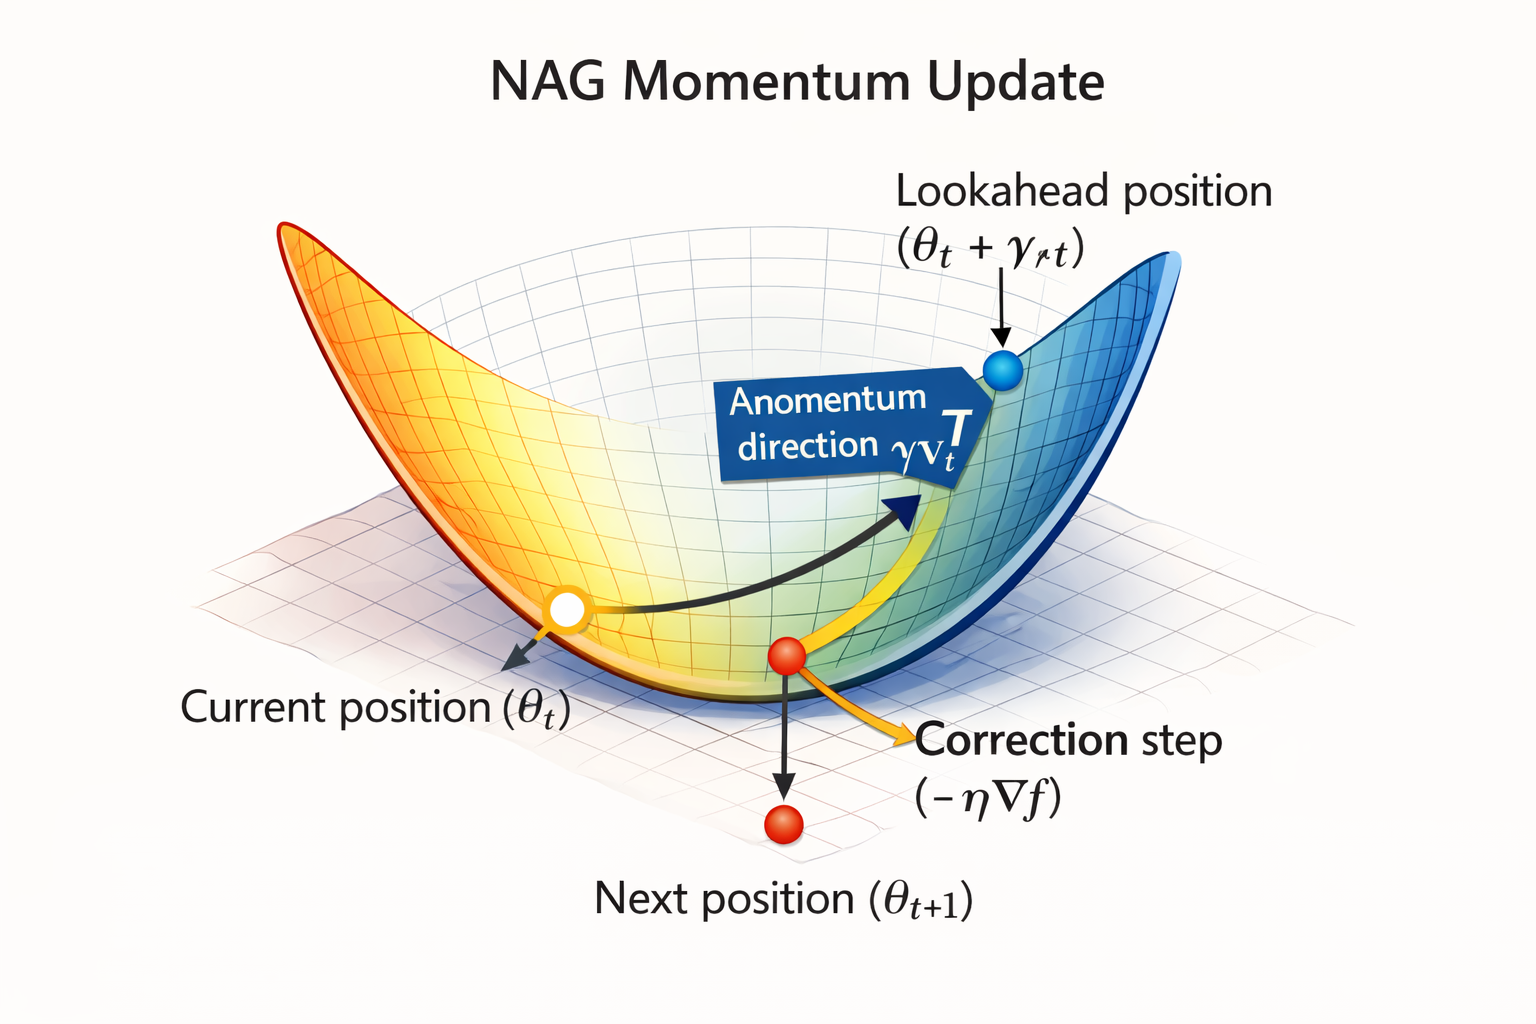

---

### Adagrad
  - Adagrad is an algorithm for gradient based optimization , It adapts the learning rate to the parameters
  - For the frequenlty occuring features low learning rates and high learning rates for infrequent features
  - For this reason adagrad is best suits for `sparse data` , mostly useful while dealing with word vestors
  - One of the main advantages of adagrad is no need to tune the learning rate manually , It is a hyperparameter.
$$
\theta_i^{(t+1)} = \theta_i^{(t)} - \frac{\eta}{\sqrt{G_i^{(t)} + \epsilon}} \cdot g_i^{(t)}
$$
##### Where:
$$
G_i^{(t)} = \sum_{k=1}^{t} (g_i^{(k)})^2
$$
**Limitations :**
  - Adagrad accumulates the squared gradients in the denominator. since every term is positive, the accumulated sum keeps growing during training,This leads to shrink the learning rates no additional information is learned

---

### Adadelta
   - Adadelta is the extension of Adagrad, Instead of accumulating all past squared gradients, Adadelta restricts the window of accumulated past gradients to some fixed size and calculates decaying average of all past gradients
   - The running average at present time stamp depends on previous gradient average + current gradient
$$
E[g^2]_t = \gamma \, E[g^2]_{t-1} + (1 - \gamma)\, g_t^2
$$
$$\gamma \ =  0.9$$
   - Diagonal matrix in Adagrad $G_t$ is replaced by $E[g^2]_t$
$$
\Delta \theta_t = - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \, g_t
$$
   - As the denominator is just a root mean squared error , we replace the denominator
$$
\Delta \theta_t = - \frac{\eta}{\text{RMS}[g]_t} \, g_t
$$
  - RMS of gradient at t time stamp is unknown,we approximate it with the RMS of parameter update until the previous time stamp. Replacing $\eta$ with previous update rule.
$$
\Delta \theta_t = - \frac{\text{RMS}[\Delta \theta]_{t-1}}{\text{RMS}[g]_t} \, g_t
$$

$$
\theta_{t+1} = \theta_t + \Delta \theta_t
$$
  - In Adadelta update rule learning rate $\eta$ is eliminated , no need of setting default learning rate

---

### RMSprop
   - Both **RMSprop** and **AdaDelta** were developed independently around the same time to address the problem of radically diminishing learning rates in AdaGrad.

   - RMSprop is in fact identical to the first update step of AdaDelta, which uses an exponentially decaying average of squared gradients.

##### Exponential Moving Average of Squared Gradients

$$
E[g^2]_t = 0.9 \, E[g^2]_{t-1} + 0.1 \, g_t^2
$$

##### Parameter Update Rule

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \, g_t
$$
##### Best default parameters suggested
- Decay rate:  
  $$
  \gamma = 0.9
  $$

- Learning rate:  
  $$
  \eta = 0.001
  $$

---

### ADAM (Adaptive moment estimstion)
- Adam is the most popular optimizer , it computes the adaptive learning rates for each parameter
- In addition to storing an exponentially decaying average of `past squared gradients` $v_t $ like in adadelta and RMSprp , adam also keeps an `exponentially decaying average of past gradients` $ m_t$.
$$
m_t = \beta m_{t-1} + (1 - \beta) g_t
$$
$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
$$
- During the initial steps $ m_t$ and $ v_t$ are baised towards zero when decaying rates are small , so the equation updated as
$$
{m}_t = \frac{m_t}{1 - \beta_1^t}
$$

$$
{v}_t = \frac{v_t}{1 - \beta_2^t}
$$ 
- Just like in RMSprop the updation happens , which yeilds the adam update rule
$$
\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

---

**Which optimizer to use when?**
- If your input data is sparse, then you likely achieve the best results using one of the adaptive learning-rate methods.No need of tuning the learning rate but acheives best results with default value
- RMSprop is an extension of adagrad that deals with its diminishing learning rates.Adam , finally adds bias-correction and momentum to RMSprop.
- RMSprop, Adadelta, and Adam are very similar algorithms that do well in similar circumstamces . bias-correction in Adam slighlty outperforms RMSprop,
  Adam might be the best overall optimizers

---